In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Data Exploration
print("Training data shape:", X_train.shape)  # (60000, 28, 28)
print("Test data shape:", X_test.shape)      # (10000, 28, 28)
print("First label:", y_train[0])

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
First label: 5


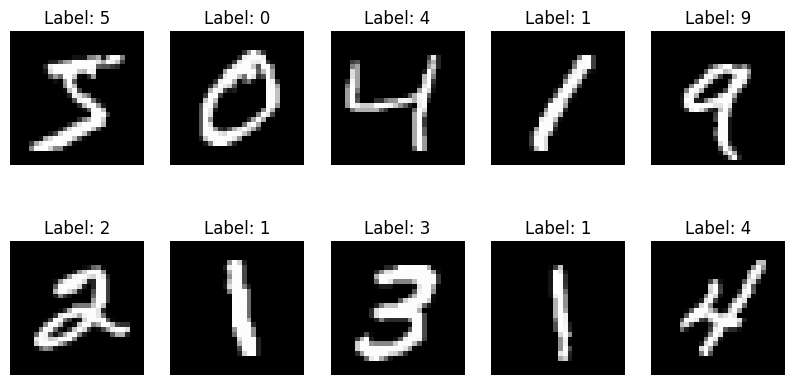

In [3]:
# Visualize sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [4]:
# Data Preprocessing

# 1. Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [5]:
# 2. Reshape data for neural network (add channel dimension)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

In [6]:
# 3. One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Shape after preprocessing:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Shape after preprocessing:
X_train: (60000, 28, 28, 1)
y_train: (60000, 10)
X_test: (10000, 28, 28, 1)
y_test: (10000, 10)


In [8]:
# Build a simple neural network model
model = Sequential([
    Flatten(input_shape=(28, 28, 1)),  # Flatten 28x28 images to 784 pixels
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

c:\Users\Azam\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the model
history = model.fit(X_train, y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8414 - loss: 0.5559 - val_accuracy: 0.9527 - val_loss: 0.1608
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9590 - loss: 0.1399 - val_accuracy: 0.9635 - val_loss: 0.1306
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9720 - loss: 0.0914 - val_accuracy: 0.9671 - val_loss: 0.1097
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9773 - loss: 0.0706 - val_accuracy: 0.9695 - val_loss: 0.1049
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9843 - loss: 0.0509 - val_accuracy: 0.9720 - val_loss: 0.0941
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9877 - loss: 0.0409 - val_accuracy: 0.9736 - val_loss: 0.0887
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9913 - loss: 0.0296 - val_accuracy: 0.9742 - val_loss: 0.0901
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9931 - loss: 0.0226 - val_accuracy: 0.

In [11]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc*100:.2f}%")


Test accuracy: 97.39%


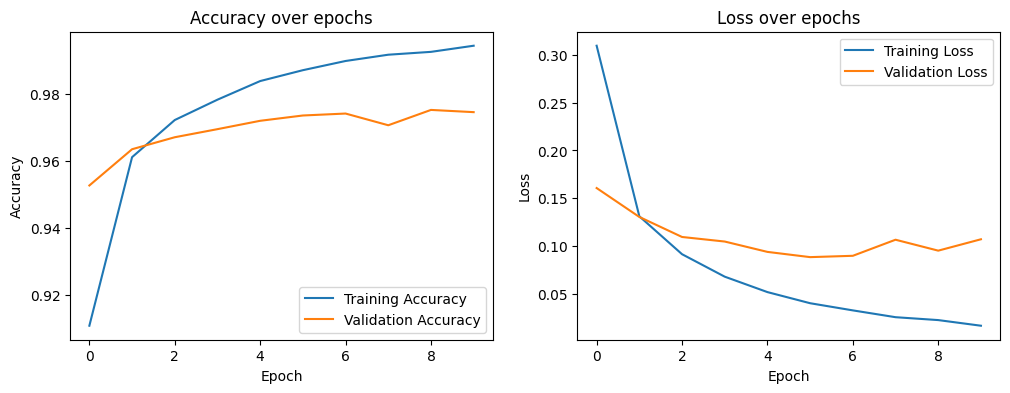

In [12]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [14]:
# Get predictions for training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [16]:
# Convert from one-hot encoded to class labels
y_train_true = np.argmax(y_train, axis=1)
y_train_pred = np.argmax(y_train_pred, axis=1)
y_test_true = np.argmax(y_test, axis=1)
y_test_pred = np.argmax(y_test_pred, axis=1)


In [17]:
# Function to plot actual vs predicted
def plot_actual_vs_predicted(actual, predicted, title, sample_size=100):
    plt.figure(figsize=(15, 6))
    indices = np.random.choice(len(actual), size=sample_size, replace=False)
    
    for i, idx in enumerate(indices):
        plt.subplot(10, 10, i+1)
        plt.imshow(X_train[idx].reshape(28, 28), cmap='gray')
        plt.title(f"A:{actual[idx]}\nP:{predicted[idx]}", fontsize=8)
        plt.axis('off')
    
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


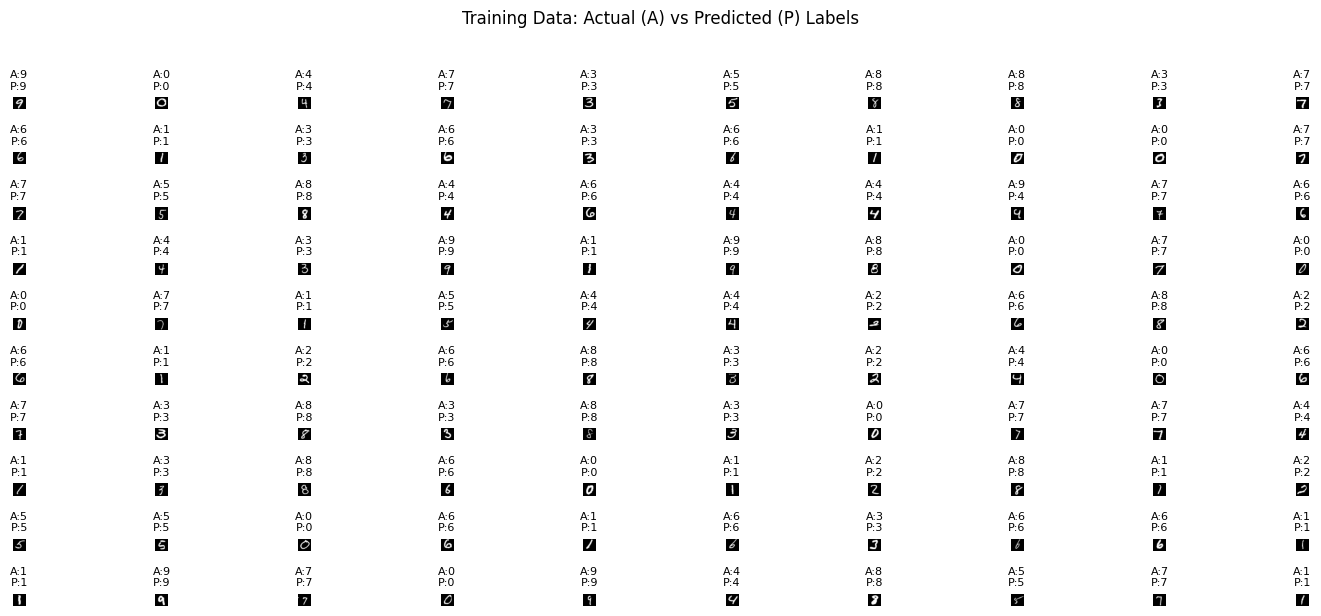

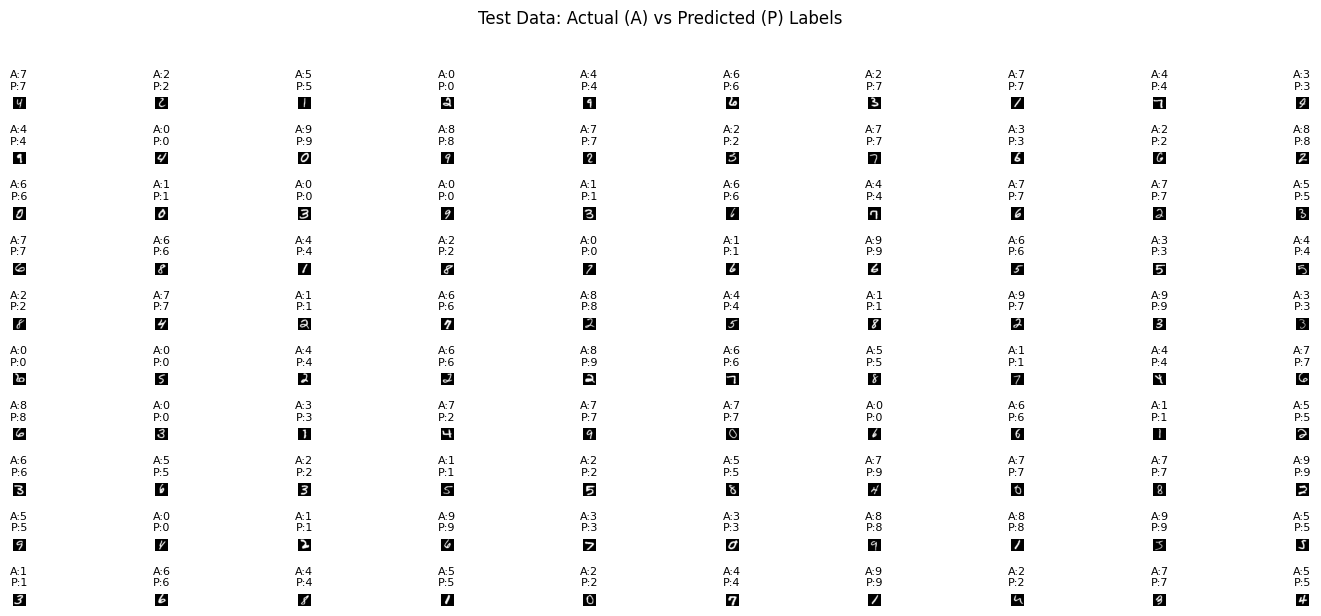

In [30]:
# Plot for training data
plot_actual_vs_predicted(y_train_true, y_train_pred, 
                        "Training Data: Actual (A) vs Predicted (P) Labels")

# Plot for test data
plot_actual_vs_predicted(y_test_true, y_test_pred, 
                        "Test Data: Actual (A) vs Predicted (P) Labels")



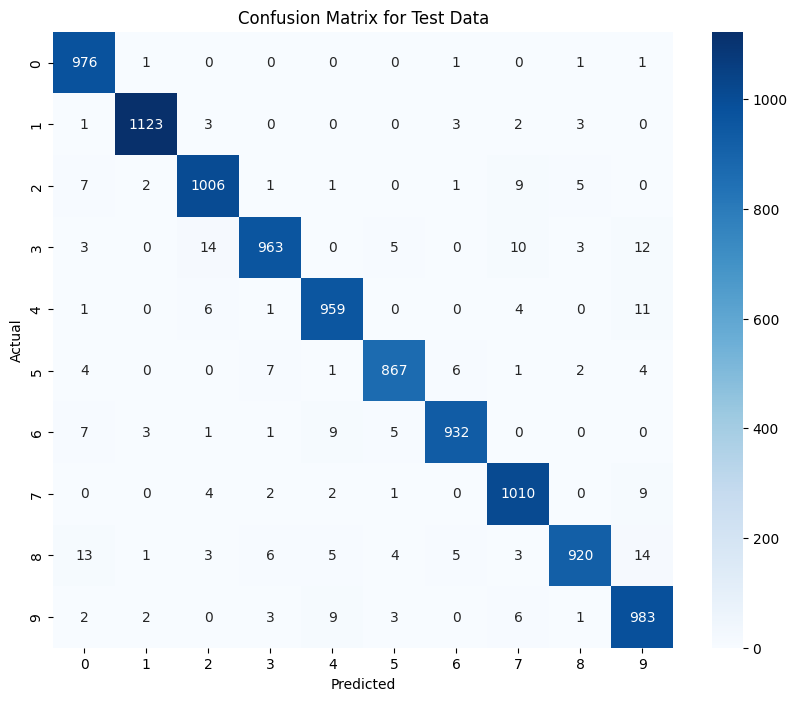

In [18]:
# Confusion Matrix for test data
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Test Data')
plt.show()

Number of misclassified test samples: 261/10000


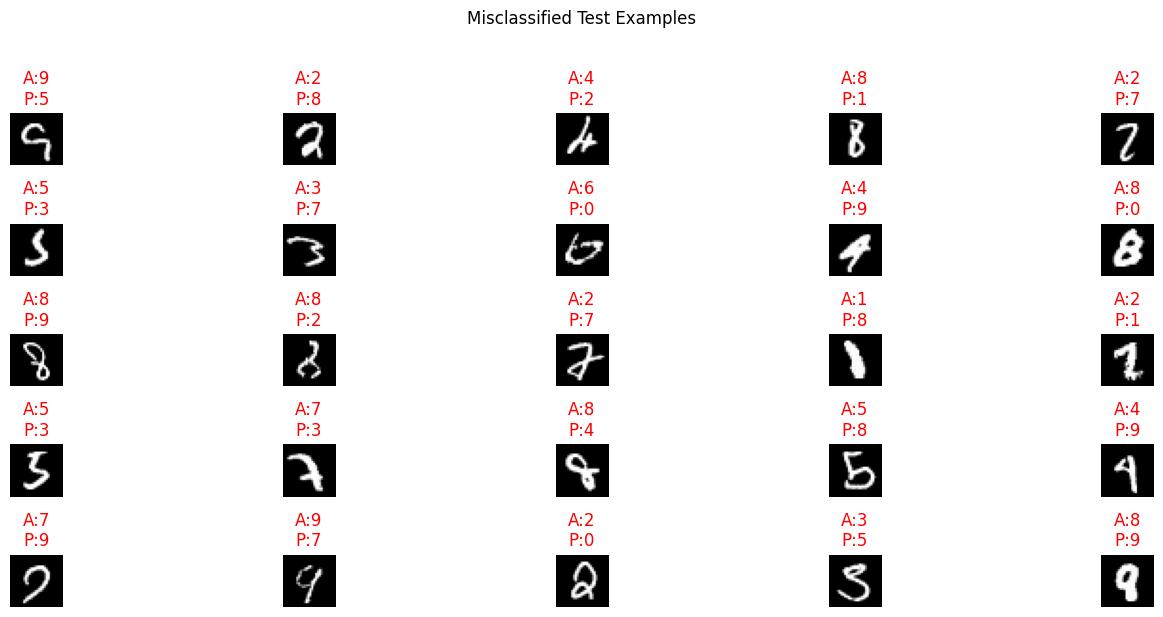

In [19]:
# Calculate and display misclassified examples
misclassified = np.where(y_test_true != y_test_pred)[0]
print(f"Number of misclassified test samples: {len(misclassified)}/{len(y_test)}")

if len(misclassified) > 0:
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(misclassified[:25]):  # Show first 25 misclassified
        plt.subplot(5, 5, i+1)
        plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        plt.title(f"A:{y_test_true[idx]}\nP:{y_test_pred[idx]}", color='red')
        plt.axis('off')
    plt.suptitle('Misclassified Test Examples', y=1.02)
    plt.tight_layout()
    plt.show()